# 4. Model with UltraNest + SMBHB

This notebook is used to test the `UltraNest` modelling of the simulated light curves. It contains the following sections modelling:

- 4.1: White noise + Spikey fiducial
- 4.2: PlatoSim + Spikey fiducial

Last tested with PlatoSim version: `3.7.0-135-g178ce335`

In [59]:
%load_ext autoreload
%autoreload 2
%matplotlib notebook

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [60]:
# Built-in
import os
import json
import datetime

# PlatoSim standard
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from astropy import constants as c
from pathlib import Path

# UltraNest packages
import ultranest
import ultranest.stepsampler
from ultranest import ReactiveNestedSampler
from ultranest.plot import cornerplot

# PlatoSim libraries
import platosim.smbhb as smbhb
import platosim.utilities as ut
from platosim.matplotlibrc import setup_notebook
setup_notebook()

from IPython.display import display, HTML
display(HTML("<style>.container {width:90% !important; }</style>"))

In [61]:
# Paths to where data is stored
path = Path(os.getenv('PLATO_WORKDIR')) / 'smbhb'
fdir = path / 'figures'
rdir = path / 'results'

---
## 1. White-noise light curve of Spikey
---

### Create input model

First we create a time array for the model:

In [62]:
tdur = 3 * ut.year() / 86400
dt   = 1
time = smbhb.time(tdur, dt)

Model parameters of Spikey (Hu+2020, Table 1)

In [63]:
# All unit are CGS or normalised
M1 = 10**7.4 # [M_sun]
M2 = 10**6.7 # [M_sun]
z     = 0.962
t0    = 1.050
P     = 1.144
i     = np.rad2deg(np.arccos(0.140))
e     = 0.524
w     = np.rad2deg(1.477)
logM  = np.log10(M2 + M1)
q     = M2 / M1
L     = 0.89
alpha = 2.09
vz    = 0
tau   = 434   # [day] (434 days paper)
sigma = 3400  # [ppm] (3400 ppm paper)

Initialise model parameters:

In [64]:
params = smbhb.model_params()
params.z     = z
params.t0    = t0
params.P     = P
params.i     = i
params.e     = e
params.w     = w
params.logM  = logM
params.q     = q
params.L     = L
params.alpha = alpha
params.vz    = vz
params.tau   = tau
params.sigma = sigma  
params.seed  = 123456789

Initialise model with model parameters:

In [65]:
model = smbhb.model(params)

Generate the light curve model:

In [66]:
dm = model.light_curve(time, df=True)

Create data frame with model time series:

In [67]:
dv = pd.DataFrame()
dv['time'] = df.time
dv['flux'] = df.flux

Create data frame with model components and plot it:

<IPython.core.display.Javascript object>


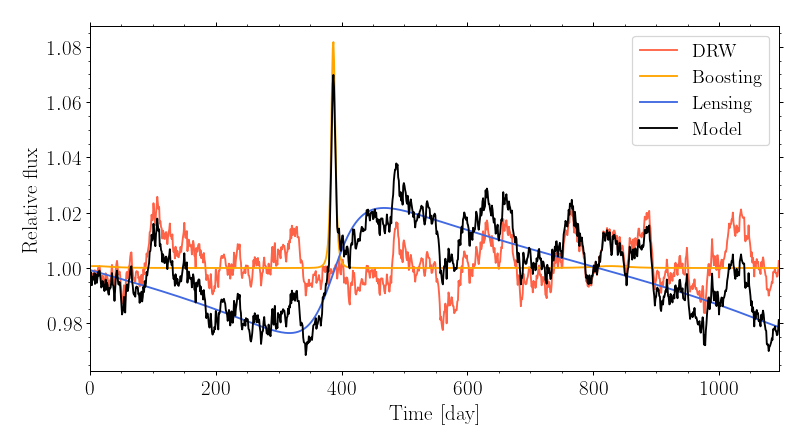

In [68]:
smbhb.plot_model(dm); 

Add some Gaussian noise to to the model:

<IPython.core.display.Javascript object>


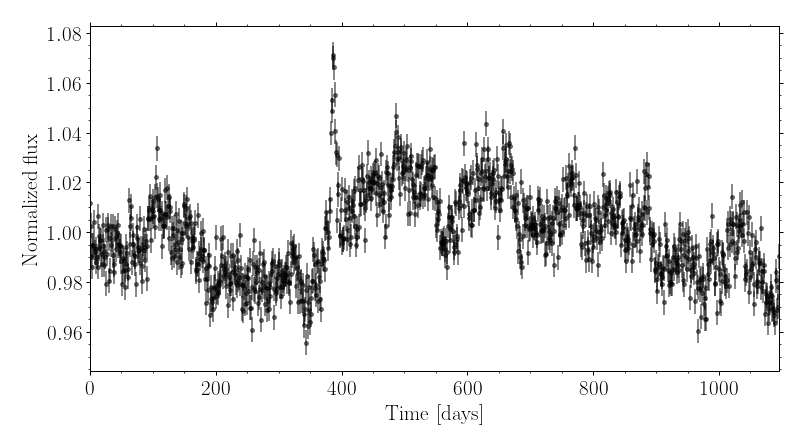

In [69]:
df = dv.copy()
noise_level = 5e-3  # [pp1]
df.flux += np.random.normal(0, noise_level, len(time))
df['flux_err'] = np.full(df.shape[0], noise_level)
smbhb.plot_lc(df); 

### Model with UltraNest + SMBHB

Define priors:

In [70]:
priors = smbhb.model_priors()
priors.z     = z
priors.t0    = [t0*0.95, t0*1.05]
priors.P     = [P*0.5, P*1.5]
priors.i     = [50, 90]
priors.e     = [0, 0.9]
priors.w     = [70, 150]
priors.logM  = [6, 11]
priors.q     = [0, 1]
priors.L     = [0, 1]
priors.alpha = [0, 4]
priors.vz    = vz

Run UltraNest on our simulated light curve:

In [ ]:
result, sampler = smbhb.run_ultranest(df, priors, rdir, nsteps=1000, live_points=1000)

[ultranest] Sampling 1000 live points from prior ...


In [42]:
# result

Plot best-fit light curve

In [ ]:
smbhb.plot_result(df, result, z);

Make a pretty corner plot:

In [ ]:
values_input = np.array([t0, P, i, e, w, logM, q, L, alpha])
fig = smbhb.plot_corner(result, bestfit='maximum', values_input=values_input);

Timing of different runs:

In [82]:
# Default setup:
# z = params.z
# t_lo, t_hi = 0.9, 1.1  # 1.05
# P_lo, P_hi = 1.0, 1.2  # 1.114
# i_lo, i_hi = 70.0, 90.0  # 81.952
# e_lo, e_hi = 0.4, 0.6  # 0.524
# w_lo, w_hi = 50., 120.  # 84.6258
# M_lo, M_hi = 7, 8.     # 7.479
# q_lo, q_hi = 0.0, 0.3  # 0.1995
# L_lo, L_hi = 0.7, 1.0  # 0.89
# a_lo, a_hi = 0.1, 3.0  # 2.09
# vz = params.vz
# nsteps=1000, live_points=400
# Execution time: 0:04:37.861366 [h:mm:ss]
# logZ = -575.932 +- 0.321

In [83]:
# Changes: allowing int ranges (and not solely float)
# Execution time: 0:04:38.430958 [h:mm:ss]
# logZ = -575.996 +- 0.327

In [84]:
# Changes:
# q_lo, q_hi = 0, 1  # 0.1995
# L_lo, L_hi = 0, 1  # 0.89
# Execution time: 1:31:09.028804 [h:mm:ss]
# logZ = -576.347 +- 0.446

In [85]:
# Changes: live_points=1000
# Execution time: 0:27:46.053724 [h:mm:ss]
# logZ = -576.937 +- 0.220

---
## 2. PlatoSim light curve of Spikey
---